# 01. Data and Model

Fit a Bayesian Marketing Mix Model using simulated consumer-goods data from PyMC-Marketing.


In [26]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.multidimensional import MMM

In [27]:
DATA_URL = "https://raw.githubusercontent.com/pymc-labs/pymc-marketing/main/data/mock_cgp_data.csv"
DATA_PATH = Path("demo/data/mock_cgp_data.csv")

DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    pd.read_csv(DATA_URL).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH, parse_dates=["Weeks"])

df.head()

,Weeks,Google Search,DV360,Facebook,AMS,TV,VOD,OOH,Radio,Numeric Distribution,RSP,Promotion,target1,target2,target_seasonal,target_upwards
0,2020-01-06,2.414281,3.179336,2.112389,1.326498,13.974318,1.544316,4.754408,0.000000,0.741301,3.643304,0.969624,8.126478,6.840064,12.862564,5.362564
1,2020-01-13,1.953829,3.712402,1.122114,0.841185,8.097841,1.458398,5.536986,0.000000,0.701279,3.643304,0.853508,7.033357,5.944537,12.417151,4.948952
2,2020-01-20,1.445275,6.610630,3.793022,0.885655,11.670006,2.742102,0.000000,0.854066,0.712682,3.643304,0.974842,9.265676,6.553764,13.315371,5.914916
3,2020-01-27,3.695156,2.694912,2.016691,1.130929,9.872921,4.760902,0.000000,0.963224,0.718657,3.643304,1.000000,9.445138,7.825555,14.054197,6.756646
4,2020-02-03,1.909138,3.047636,1.887042,1.478925,7.598348,2.926870,0.000000,1.475399,0.713845,3.643304,0.937466,8.671742,6.847199,13.570238,6.409459


In [28]:
DATE = "Weeks"
CHANNELS = [
    "Google Search",
    "DV360",
    "Facebook",
    "AMS",
    "TV",
    "VOD",
    "OOH",
    "Radio",
]

CONTROLS = [
    "Numeric Distribution",
    "RSP",
    "Promotion",
]
TARGET = "target_seasonal"

df = df[[DATE, *CHANNELS, *CONTROLS, TARGET]]

print(df.shape)
df.describe()

(365, 13)


,Weeks,Google Search,DV360,Facebook,AMS,TV,VOD,OOH,Radio,Numeric Distribution,RSP,Promotion,target_seasonal
count,365,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2023-07-03 00:00:00,2.217827,3.445572,2.098098,1.706826,14.033553,2.970981,7.118491,1.543534,0.796888,3.854293,0.911618,12.272323
min,2020-01-06 00:00:00,1.047788,1.601873,0.774239,0.619639,0.000000,0.420461,0.000000,0.000000,0.537044,3.456516,0.708443,7.911417
25%,2021-10-04 00:00:00,1.619056,2.547655,1.458022,1.151885,9.271226,1.802338,4.367724,0.709456,0.744768,3.772808,0.866010,10.623038
50%,2023-07-03 00:00:00,1.925589,3.039579,1.764620,1.442006,12.703907,2.629420,6.313286,1.139943,0.810860,3.871714,0.916832,12.408570
75%,2025-03-31 00:00:00,2.386296,3.747809,2.233468,1.796656,16.428118,3.455183,8.813714,2.312537,0.855192,3.934013,0.963584,13.838269
max,2026-12-28 00:00:00,5.924566,8.522803,8.867833,6.394341,42.777737,9.464257,34.234847,5.036427,0.940265,4.168038,1.000000,18.007455
std,NaN,0.923242,1.357814,1.089417,0.935993,7.359857,1.694734,4.708247,1.156565,0.082797,0.142821,0.066310,2.019333


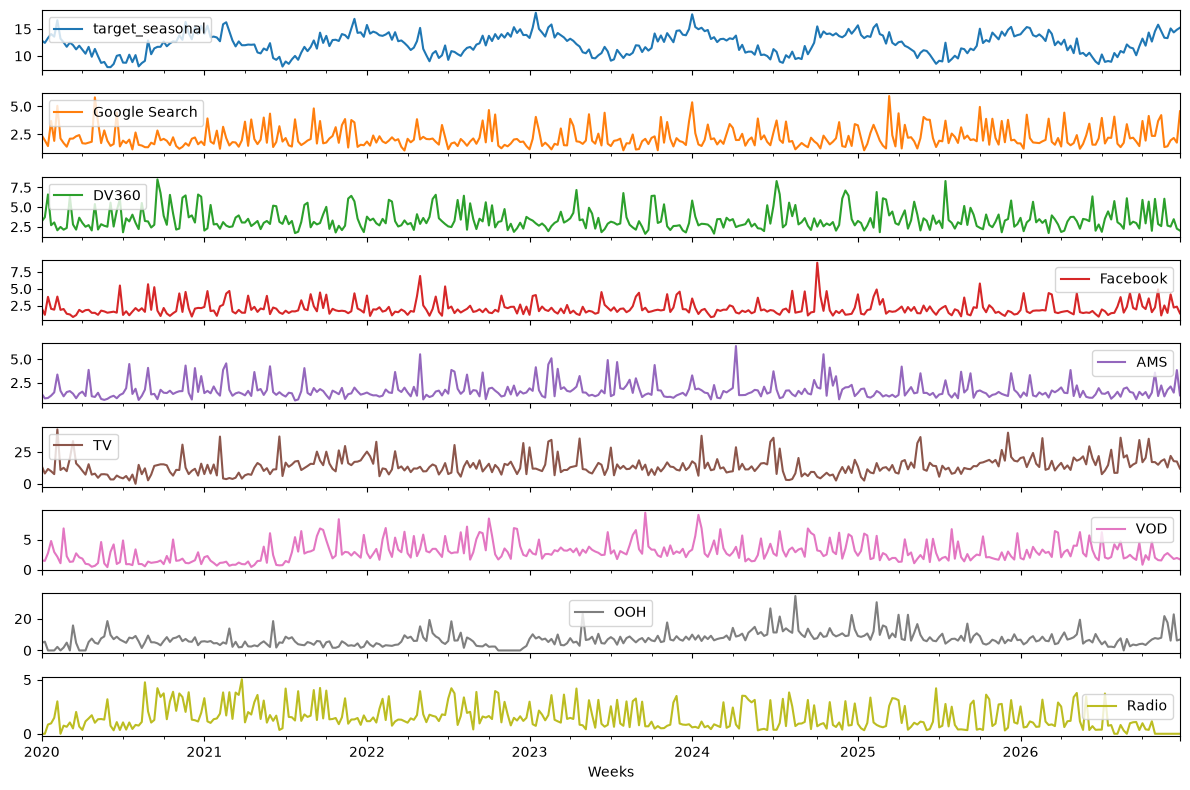

In [29]:
df.set_index(DATE)[[TARGET, *CHANNELS]].plot(
    subplots=True,
    figsize=(12, 8),
    sharex=True
)

plt.tight_layout()
plt.show()

In [30]:
TEST_WEEKS = 52

train = df.iloc[:-TEST_WEEKS].copy()
test = df.iloc[-TEST_WEEKS:].copy()

X_train = train[[DATE, *CHANNELS, *CONTROLS]]
y_train = train[TARGET]

X_test = test[[DATE, *CHANNELS, *CONTROLS]]
y_test = test[TARGET]

print("Train:", len(train))
print("Test:", len(test))

Train: 313
Test: 52


In [31]:
mmm = MMM(
    date_column=DATE,
    target_column=TARGET,
    channel_columns=CHANNELS,
    control_columns=CONTROLS,
    adstock=GeometricAdstock(l_max=10),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)

mmm.build_model(
    X=X_train,
    y=y_train,
)

mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

mmm.fit(
    X_train,
    y_train,
    chains=4,
    draws=1000,
    tune=1200,
    target_accept=0.85,
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_200 tune and 1_000 draw iterations (4_800 + 4_000 draws total) took 187 seconds.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data
	> fit_data

In [34]:
summary = az.summary(
    mmm.idata,
    var_names=[
        "adstock_alpha",
        "saturation_lam",
        "saturation_beta",
        "gamma_control",
    ],
    round_to=3,
)

display(summary)
print("Max R-hat:", summary["r_hat"].max())

MODEL_PATH = Path("demo/artifacts/mmm_demo_8ch.nc")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

mmm.save(MODEL_PATH)

print("Saved:", MODEL_PATH)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
adstock_alpha[Google Search],0.028,0.019,0.000,0.062,0.000,0.000,2648.959,1278.485,1.001
adstock_alpha[DV360],0.423,0.096,0.245,0.608,0.002,0.002,3177.213,1951.770,1.001
adstock_alpha[Facebook],0.106,0.027,0.058,0.158,0.000,0.000,3045.659,1630.792,1.001
adstock_alpha[AMS],0.081,0.027,0.025,0.129,0.001,0.001,2769.132,1243.351,1.001
adstock_alpha[TV],0.371,0.212,0.000,0.706,0.004,0.002,2626.566,1875.090,1.000
adstock_alpha[VOD],0.509,0.060,0.395,0.618,0.001,0.001,3886.125,2658.023,1.002
adstock_alpha[OOH],0.360,0.241,0.000,0.774,0.004,0.003,3251.588,2141.003,1.000
adstock_alpha[Radio],0.867,0.034,0.799,0.929,0.001,0.001,3274.090,2015.409,1.003
saturation_lam[Google Search],1.142,0.442,0.334,1.940,0.011,0.007,1641.988,1162.881,1.001
saturation_lam[DV360],1.129,0.704,0.073,2.425,0.013,0.012,2019.942,1432.364,1.002


Max R-hat: 1.004
Saved: demo/artifacts/mmm_demo_8ch.nc
